In [5]:
#Als Stadtverkehrsplaner möchte ich Zeitdaten nutzen, um saisonale und tagesabhängige Verkehrsprobleme zu identifizieren

import pandas as pd
df = pd.read_parquet("yellow_tripdata_2025-01.parquet")

In [29]:
pickup_col = [c for c in df.columns if "pickup" in c.lower() and "time" in c.lower()][0]
df = df.rename(columns={pickup_col: "pickup_datetime"})
df["hour"] = pd.to_datetime(df["pickup_datetime"]).dt.hour
df["hour"].tail(3)

3475223    23
3475224    23
3475225    23
Name: hour, dtype: int32

In [25]:
by_pu_hour = df.groupby(["PULocationID","hour"]).size().reset_index(name="trip_count")
by_pu_hour.tail()

,PULocationID,hour,trip_count
5654,265,19,69
5655,265,20,79
5656,265,21,60
5657,265,22,73
5658,265,23,87


In [14]:
top_pu = by_pu_hour.groupby("PULocationID")["trip_count"].sum().nlargest(10).index

In [15]:
top_pu

Index([161, 237, 236, 132, 230, 186, 162, 142, 239, 163], dtype='int32', name='PULocationID')

In [16]:
top_data = by_pu_hour[by_pu_hour["PULocationID"].isin(top_pu)]


In [30]:
top_data.head(4)

,PULocationID,hour,trip_count
2692,132,0,5634
2693,132,1,2398
2694,132,2,968
2695,132,3,641


In [18]:
pivot = top_data.pivot(index="PULocationID", columns="hour", values="trip_count").fillna(0)
pivot


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
PULocationID,,,,,,,,,,,,,,,,,,,,,
132,5634,2398,968,641,756,2478,4159,4798,3687,3467,...,8144,10357,11596,9763,8778,10247,10453,10403,9624,8545
142,2021,706,281,129,193,316,810,2794,4377,4325,...,6625,6940,6567,7420,8424,6654,6613,10643,8069,5421
161,2102,914,425,276,251,320,1009,1894,3366,4869,...,11107,11489,12969,16465,17372,13961,13331,12065,8748,4356
162,1332,673,298,242,203,538,1817,3078,4525,4966,...,6456,6883,7915,11106,12358,9343,8164,6761,4544,2555
163,1590,799,455,240,246,322,569,1478,2306,2990,...,6547,6502,6743,8007,8866,6933,6026,6233,5686,3226
186,2484,1246,795,489,444,1352,3027,4612,5759,6296,...,6191,6429,6882,8401,7506,6680,5706,8362,6635,3890
230,2924,1311,736,660,698,611,982,1900,2979,3846,...,5635,6339,7806,9308,9721,8012,9103,13579,12578,6239
236,670,368,197,97,154,486,1900,6689,9509,9560,...,11945,13565,11644,12687,11738,7975,5887,4939,2940,1429
237,1616,796,356,185,177,312,1142,4400,6566,7599,...,13211,12767,11918,12733,12738,9714,8422,8232,5857,3355


In [19]:
peak_hour  = pivot.idxmax(axis=1)            
peak_count = pivot.max(axis=1).astype(int)
peaks = pd.DataFrame({"peak_hour": peak_hour, "peak_trips": peak_count}).sort_values("peak_trips", ascending=False)
peaks


,peak_hour,peak_trips
PULocationID,,
161,18,17372
230,21,13579
236,15,13565
237,14,13211
162,18,12358
132,16,11596
142,21,10643
163,18,8866
186,17,8401


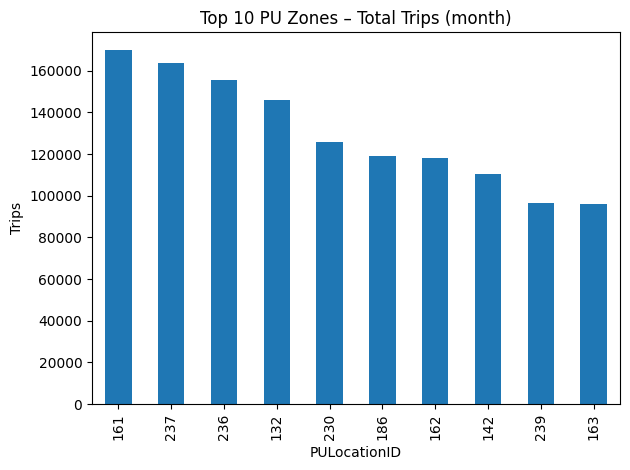

In [20]:
import matplotlib.pyplot as plt

totals = by_pu_hour.groupby("PULocationID")["trip_count"].sum().loc[top_pu].sort_values(ascending=False)

plt.figure()
totals.plot(kind="bar")
plt.title("Top 10 PU Zones – Total Trips (month)")
plt.xlabel("PULocationID")
plt.ylabel("Trips")
plt.tight_layout()
plt.show()


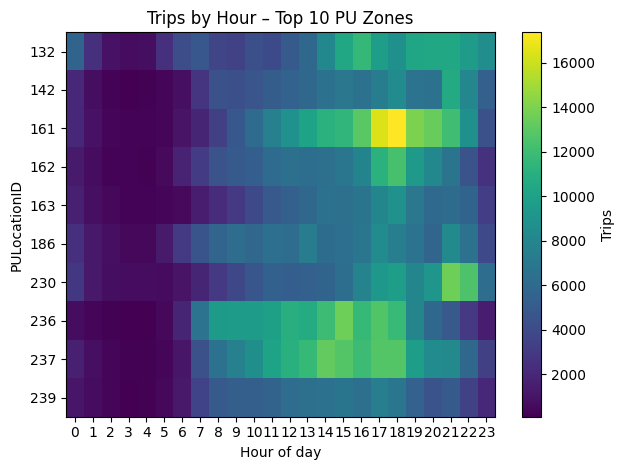

In [21]:
import numpy as np

# pivot: index=ZoneID, columns=hour 0..23
plt.figure()
plt.imshow(pivot.values, aspect="auto", interpolation="nearest")
plt.colorbar(label="Trips")
plt.xticks(ticks=np.arange(pivot.shape[1]), labels=pivot.columns)
plt.yticks(ticks=np.arange(pivot.shape[0]), labels=pivot.index)
plt.xlabel("Hour of day")
plt.ylabel("PULocationID")
plt.title("Trips by Hour – Top 10 PU Zones")
plt.tight_layout()
plt.show()


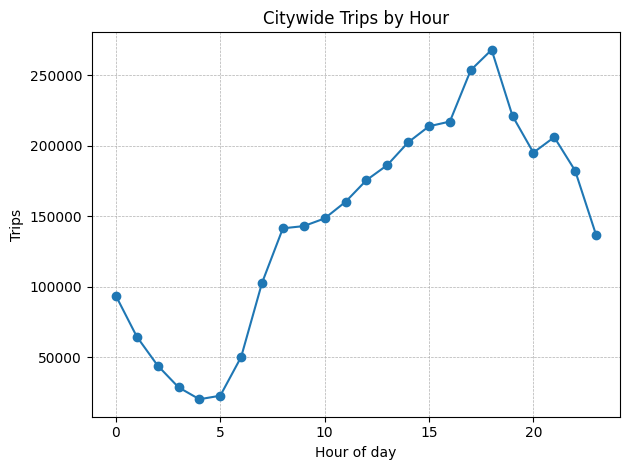

In [22]:
by_hour_city = df.groupby("hour").size()

plt.figure()
by_hour_city.plot(marker="o")
plt.title("Citywide Trips by Hour")
plt.xlabel("Hour of day")
plt.ylabel("Trips")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


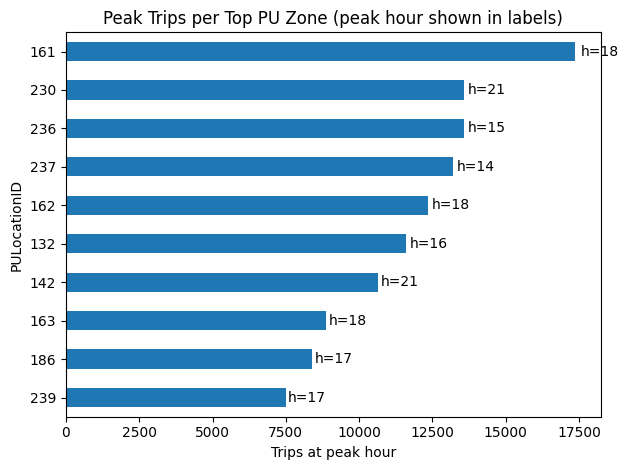

In [23]:
plt.figure()
peaks.sort_values("peak_trips", ascending=True)["peak_trips"].plot(kind="barh")
plt.title("Peak Trips per Top PU Zone (peak hour shown in labels)")

for i, (idx, row) in enumerate(peaks.sort_values("peak_trips", ascending=True).iterrows()):
    plt.text(row["peak_trips"]*1.01, i, f"h={int(row['peak_hour'])}", va="center")

plt.xlabel("Trips at peak hour")
plt.ylabel("PULocationID")
plt.tight_layout()
plt.show()
